# Project: California house price prediction
---

- Part 1: Import data
- Part 2: Numpy implementation of regression model
    1. Normal Equation
    2. MSE
    3. Gradient Descent
- Part 3: sklearn regression model
    1. LinearRegression
    2. Ridge
    3. Hyperparmeter Tuning (GridSearchCV)

## Quick Notes
---

### Part 2: Numpy implementation - summary

1. Always split data into 3 parts: train, validation, and test.
   Use validation inside the training loop for hyperparameter tuning, and keep test for final evaluation only.

2. Always normalize the feature matrix at the beginning.
   This stabilizes Gradient Descent updates and helps prevent gradient explosion.

3. A full-rank matrix guarantees a unique global minimum for the loss function.
   Gradient Descent can still achieve slightly lower test MSE than the Normal Equation because training optimization and test generalization are different.

<br>

### Part 3: Sklearn - summary

**1. Normalise validation and test data with training data's mean and std.**

**2. Scikit-learn workflow**
1. Hold out a test set once (never touched during tuning)

2. Build a Pipeline (so scaling happens correctly inside CV)

3. Use cross-validation search on the training set (GridSearchCV / RandomizedSearchCV)

4. Refit the best model on full training set

5. Evaluate once on the test set


**3. GridSearchCV parameters**
```python
search = GridSearchCV(
    estimator=model_ridge,
    param_grid=param_grid,
    scoring="neg_mean_squared_error", # sklearn maximizes
    cv=5, # 5 fold cross-validation, 4 train 1 test, rotate 5 times
    n_jobs=-1, # Compuatation core, -1: all cores
    refit=True # Apply the best params, can use to predict immediately
)
```


## Part 1: Import data

In [22]:
import numpy as np
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

In [ ]:
data



{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [24]:
X = data.data
y = data.target
print(X.shape, y.shape)

(20640, 8) (20640,)


In [25]:
# train test split
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2,random_state=21)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.2, random_state=21)

## Part 2: Numpy implementation of regression model

### 2.1 Normal Equation

$$
w = \left(X^\top X\right)^{-1} X^\top y
$$

In [26]:
## Normalise feature matrix by columns
def normalise_feature(X):
    return ((X - X.mean(axis=0)) / X.std(axis=0))

Xn_train = normalise_feature(X_train)
Xn_val = normalise_feature(X_val)
Xn_test = normalise_feature(X_test)

In [27]:
## Bias trick
Xbn_train = np.hstack([np.ones((Xn_train.shape[0], 1)), Xn_train])
Xbn_test = np.hstack([np.ones((Xn_test.shape[0], 1)), Xn_test])
Xbn_val = np.hstack([np.ones((Xn_val.shape[0], 1)), Xn_val])

Xbn_train.shape

(13209, 9)

In [28]:
## Implementing normal equation
XtX = Xbn_train.T @ Xbn_train

## Check if the matrix is full rank (invertible)
print(XtX.shape[0])
print(np.linalg.matrix_rank(XtX))

9
9


In [29]:
# Optimal weighting 
w_neq = (np.linalg.inv(XtX) @ Xbn_train.T) @ y_train
w_neq

array([ 2.06968008,  0.84862813,  0.1161058 , -0.29293027,  0.30771951,
       -0.0039855 , -0.02703708, -0.88593838, -0.85998229])

### 2.2 Mean Squared Error (MSE)

$$
\mathrm{MSE} = \frac{1}{m}\sum_{i=1}^{m}\left(y_i - \hat{y}_i\right)^2
$$


In [30]:
# Testing
y_neq = Xbn_test @ w_neq

def mse(y1, y2):
    return np.mean((y1 - y2) ** 2)

MSE_neq = mse(y_test, y_neq)

print(f"MSE: {MSE_neq}")


MSE: 0.5333166835581649


### 2.3 Gradient Descent

The weight update rule is:

$$
\mathbf{w}_{(t+1)} \leftarrow \mathbf{w}_{(t)} - \alpha \, \nabla_{\mathbf{w}} L \Big|_{\mathbf{w}=\mathbf{w}_{(t)}}
$$

where 

$$
L(\mathbf{w})=\frac{1}{2}\sum_{i=1}^{m}\left(y^{(i)}-\mathbf{w}^{\top}\mathbf{x}^{(i)}\right)^2
=\frac{1}{2}\left\|\mathbf{y}-\mathbf{X}\mathbf{w}\right\|_2^2, \qquad \nabla_{\mathbf{w}}L=\mathbf{X}^{\top}\left(\mathbf{X}\mathbf{w}-\mathbf{y}\right)

$$





In [31]:
def grad_L(w):
    return (2/Xbn_train.shape[0])*(Xbn_train.T @ (Xbn_train @ w - y_train))

In [32]:
import matplotlib.pyplot as plt

lr = 0.1
epoch = 300
w_gd = np.random.rand(Xbn_train.shape[1])
mse_record = []

for i in range(epoch):
    w_cur = w_gd - lr * grad_L(w_gd)
    g = grad_L(w_gd)
    
    w_gd = w_cur
    y_gd = Xbn_val @ w_gd
    MSE_gd_curr = mse(y_gd, y_val)
    
    print(f"Epoch {i+1} | MSE: {MSE_gd_curr}") 
    mse_record.append(MSE_gd_curr)

Epoch 1 | MSE: 3.4754615718574344
Epoch 2 | MSE: 2.271672418075906
Epoch 3 | MSE: 1.6286710970157128
Epoch 4 | MSE: 1.2646655169605805
Epoch 5 | MSE: 1.0485568750839698
Epoch 6 | MSE: 0.9153988184011826
Epoch 7 | MSE: 0.8309192918353214
Epoch 8 | MSE: 0.7759829087494292
Epoch 9 | MSE: 0.7394090766856601
Epoch 10 | MSE: 0.714441286593817
Epoch 11 | MSE: 0.6968989492514792
Epoch 12 | MSE: 0.6841534084168331
Epoch 13 | MSE: 0.6745337207038996
Epoch 14 | MSE: 0.6669696778384665
Epoch 15 | MSE: 0.6607720520459479
Epoch 16 | MSE: 0.6554950480717239
Epoch 17 | MSE: 0.6508492406907369
Epoch 18 | MSE: 0.6466460459337373
Epoch 19 | MSE: 0.6427621140396075
Epoch 20 | MSE: 0.6391164057729222
Epoch 21 | MSE: 0.6356553875780322
Epoch 22 | MSE: 0.6323434445814641
Epoch 23 | MSE: 0.6291566576687937
Epoch 24 | MSE: 0.6260787553249552
Epoch 25 | MSE: 0.623098474835867
Epoch 26 | MSE: 0.6202078389586066
Epoch 27 | MSE: 0.617401028596454
Epoch 28 | MSE: 0.614673644361352
Epoch 29 | MSE: 0.6120222224327819

In [33]:
y_gd = Xbn_test @ w_gd
MSE_gd = mse(y_test, y_gd)

print(f"MSE GD: {MSE_gd} | MSE NEQ: {MSE_neq}")

MSE GD: 0.5340947936587346 | MSE NEQ: 0.5333166835581649


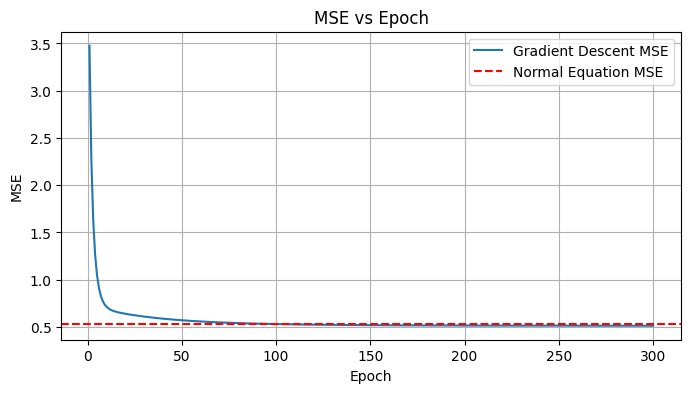

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, epoch + 1), mse_record, label="Gradient Descent MSE")
plt.axhline(MSE_neq, color="r", linestyle="--", label="Normal Equation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE vs Epoch")
plt.legend()
plt.grid(True)
plt.show()


## Part 3: Sklearn regression model

### 3.1: LinearRegression()

Q: Why normalise test and validation data with train data's mean and std?

A:

- Ensures fair evaluation:
  - Metrics reflect how the model performs on truly unseen data.
  - New samples are transformed with the same scaler learned from training data.

- Avoids unstable preprocessing:
  - Recomputing mean/std on each new batch makes predictions inconsistent over time.
  - Fixed train-based normalization gives deterministic and comparable results.



In [35]:
## Normalise data (sklearn handles bias term)
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # remembers X_train's mean and std (columnwise)
X_test = scaler.transform(X_test)

Q: Does sklearn LinearRegression() use normal equation or gradient descent?

A:
- `sklearn.linear_model.LinearRegression` does **not** use gradient descent.
- It solves ordinary least squares with a **direct linear algebra solver** (e.g., least-squares/SVD-based methods).
- So conceptually it gives the closed-form OLS solution (normal-equation equivalent), not iterative GD updates.

Q: What if the feature matrix X is not full rank ( $X^{T}X$ not invertible)?

- If `X` is not full rank, then `X^T X` is singular (not invertible).
- The normal-equation form `w = (X^T X)^{-1} X^T y` cannot be used directly.
- sklearn uses numerical least-square solver (SVD/QR) to prevent matrix inversion


In [36]:
## Use model
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True) # Bias term included

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [37]:
## Evaluate
from sklearn.metrics import mean_squared_error
MSE_sk = mean_squared_error(y_pred, y_test)

print(f"MSE (LinearRegression): {MSE_sk}")

MSE (LinearRegression): 0.5416111027038727


### 3.2 Ridge Regression

$$
L_{\text{ridge}}(\mathbf{w})=\frac{1}{2m}\left\|\mathbf{y}-\mathbf{X}\mathbf{w}\right\|_2^2+\frac{\alpha}{2m}\left\|\mathbf{w}\right\|_2^2
$$

$$
\mathbf{w}_{\text{ridge}}=\left(\mathbf{X}^{\top}\mathbf{X}+\alpha \mathbf{I}\right)^{-1}\mathbf{X}^{\top}\mathbf{y}
$$

Note: As $(\mathbf{X}^{\top}\mathbf{X}+\lambda)$ is positive definite, therefore revised normal equation is always solvable

In [38]:
## Use Ridge
from sklearn.linear_model import Ridge
model_ridge = Ridge()

model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

MSE_ridge = mean_squared_error(y_pred_ridge, y_test)

print(f"MSE (Ridge): {MSE_ridge}")

MSE (Ridge): 0.5416106898523476


### 3.3 Hyperparameter Tuning

Q: What is GridSearchCV in scikit-learn?

A:
GridSearchCV is a scikit-learn utility for **systematic hyperparameter tuning**.

- It tries **all combinations** in a parameter grid.
- It evaluates each combination using **cross-validation**.
- It selects the best setting based on a scoring metric, then can **refit** on the full training set.



In [39]:
from sklearn.model_selection import GridSearchCV

## 1. Define range of parameter (in dictionary)
param_grid = {"alpha": np.logspace(-4, 4, 25)} #1e-4, ... ,1e4

## 2. CV search on train
search = GridSearchCV(
    estimator=model_ridge,
    param_grid=param_grid,
    scoring="neg_mean_squared_error", # sklearn maximizes
    cv=5, # 5 fold cross-validation, 4 train 1 test, rotate 5 times
    n_jobs=-1, # Compuatation core, -1: all cores
    refit=True # Apply the best params, can use to predict immediately
)

search.fit(X_train, y_train)
print(f"Best alpha: {search.best_params_}")
print(f"Best CV MSE: {search.best_score_}")

Best alpha: {'alpha': np.float64(46.41588833612773)}
Best CV MSE: -0.5235356636894062


In [40]:
## 3. Evaluate on test data
y_pred_rht = search.predict(X_test)
MSE_rht = mean_squared_error(y_pred_rht, y_test)

print(f"MSE (Ridge Hyperparamter Tuning): {MSE_rht}")

MSE (Ridge Hyperparamter Tuning): 0.5417669598218616


In [41]:
print(f"MSE (Normal Equation): {MSE_neq}")
print(f"MSE (Gradient Descent): {MSE_gd}")
print(f"MSE (LinearRegression): {MSE_sk}")
print(f"MSE (Ridge): {MSE_ridge}")
print(f"MSE (Ridge Hyperparameter Tuning): {MSE_rht}")

MSE (Normal Equation): 0.5333166835581649
MSE (Gradient Descent): 0.5340947936587346
MSE (LinearRegression): 0.5416111027038727
MSE (Ridge): 0.5416106898523476
MSE (Ridge Hyperparameter Tuning): 0.5417669598218616
